# Series de tiempo






Para esta clase, vamos a trabajar con datos del Banco Mundial, utilizando la API `Data360` del Banco Mundial.


Vamos a explorar brevemente la API desde su sitio web: [API World Bank](https://data360.worldbank.org/en/api#)

Este notebook ya contiene un bloque de código que descarga datos poblacionales para la Argentina de la base WB_WDI y del indicador WB_WDI_SP_POP_TOTL

---
## 1. Configuración e Imports
Instalamos e importamos las librerías necesarias y definimos la URL base de la API.

In [91]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# import altair as alt
# alt.renderers.enable('colab')
# alt.data_transformers.disable_max_rows()
# from IPython.display import display

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', 80)

BASE_URL = "https://data360api.worldbank.org"

---
## 2. Función para hacer peticiones a la API
A continuación, definimos dos funciones que manejan las peticiones a la API a través de Requests HTTP y devuelven la respuesta en formato JSON.

* get_api() usa el método GET, los parámetros de la consulta se incluyen en la URL
* post_api() usa el método POST, los parámetros de la consulta se incluyen por separado en el body, dentro del payload.

In [92]:
 # Realiza una petición GET a la API y retorna el JSON de respuesta
def get_api(endpoint, params=None):
    url = f"{BASE_URL}{endpoint}"
    response = requests.get(url, params=params)
    response.raise_for_status()
    return response.json()


In [93]:
 # Realiza una petición POST a la API y retorna el JSON de respuesta
def post_api(endpoint, payload):
    """Realiza una petición POST a la API y retorna el JSON de respuesta."""
    url = f"{BASE_URL}{endpoint}"
    response = requests.post(url, json=payload)
    response.raise_for_status()
    return response.json()

---
## 3. Recuperación de datos
El endpoint `/data360/data` es el núcleo de la API. Retorna observaciones con la siguiente estructura:
- **REF_AREA**: código de país o región
- **TIME_PERIOD**: año o período
- **INDICATOR**: ID del indicador
- **OBS_VALUE**: valor observado
- **SEX, AGE, URBANISATION**: dimensiones de desagregación
- **FREQ**: frecuencia (A=anual, Q=trimestral, M=mensual)

Preparamos el diccionario `params_data` de manera de traernos:
* datos de la base `"WB_WDI"`,
* del indicador `"WB_WDI_SP_POP_TOTL"`

Si desean filtrar por país, por ejemplo los registros para la Argentina, usen la línea comentada `"REF_AREA": "ARG"`

In [94]:
# preparamos los parámetros antes de ejecutar la consulta:
params_data = {
    "DATABASE_ID": "WB_WDI",
    "INDICATOR": "WB_WDI_SP_POP_TOTL",
    # "REF_AREA": "ARG",
    "skip": 0,
    "limit": 1000 # Add limit parameter for pagination
}

# como la consulta retorna páginas de hasta 1000 registros,
# si la longitud de la base supera el límite debemos iterar hasta
# descargar todos los registros:
all_data = []
total_records = 0
skip = 0

# La consulta inicial descarga los primeros 1000 registros
initial_resp = get_api("/data360/data", params=params_data)
total_records = initial_resp.get('count', 0)
all_data.extend(initial_resp.get('value', []))

# Preparamos el puntero de la siguiente página y actualizamos la consola
skip += len(initial_resp.get('value', []))
print(f"Initial Total de registros disponibles: {total_records}")
print(f"Initial Total de registros descargados: {len(all_data)}")

# Repetimos la consulta actualizando el Skip hasta completar la descarga
while skip < total_records:
    params_data["skip"] = skip
    resp_data = get_api("/data360/data", params=params_data)
    current_page_data = resp_data.get('value', [])
    all_data.extend(current_page_data)
    skip += len(current_page_data)
    print(f"Downloaded {len(all_data)} of {total_records} records...")

# data contiene todos los registros del indicador
data = all_data

print(f"\nFinal Total de registros disponibles: {total_records}")
print(f"Final Total de registros descargados: {len(data)}")
# print(data) # Uncomment if you want to see all data, but it can be very large

Initial Total de registros disponibles: 17195
Initial Total de registros descargados: 1000
Downloaded 2000 of 17195 records...
Downloaded 3000 of 17195 records...
Downloaded 4000 of 17195 records...
Downloaded 5000 of 17195 records...
Downloaded 6000 of 17195 records...
Downloaded 7000 of 17195 records...
Downloaded 8000 of 17195 records...
Downloaded 9000 of 17195 records...
Downloaded 10000 of 17195 records...
Downloaded 11000 of 17195 records...
Downloaded 12000 of 17195 records...
Downloaded 13000 of 17195 records...
Downloaded 14000 of 17195 records...
Downloaded 15000 of 17195 records...
Downloaded 16000 of 17195 records...
Downloaded 17000 of 17195 records...
Downloaded 17195 of 17195 records...

Final Total de registros disponibles: 17195
Final Total de registros descargados: 17195


Convertimos los datos en un DataFrame y exploramos su estructura.

In [95]:
# Convertimos el JSON (lista de diccionarios) a Dataframe
df = pd.DataFrame(all_data)
df.head()

,OBS_VALUE,TIME_FORMAT,UNIT_MULT,COMMENT_OBS,OBS_STATUS,OBS_CONF,AGG_METHOD,DECIMALS,COMMENT_TS,DATA_SOURCE,...,SEX,AGE,URBANISATION,COMP_BREAKDOWN_1,COMP_BREAKDOWN_2,COMP_BREAKDOWN_3,TIME_PERIOD,FREQ,UNIT_MEASURE,UNIT_TYPE
0,24476008,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None
1,182048,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None
2,24066593,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None
3,76287452,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None
4,108599,P1Y,0,None,A,PU,_Z,2,None,None,...,_T,_T,_T,_Z,_Z,_Z,1999,A,PS,None


## EDA para ver la estructura y seleccionar datos de interés

In [96]:
# Listamos las columnas
df.columns

Index(['OBS_VALUE', 'TIME_FORMAT', 'UNIT_MULT', 'COMMENT_OBS', 'OBS_STATUS',
       'OBS_CONF', 'AGG_METHOD', 'DECIMALS', 'COMMENT_TS', 'DATA_SOURCE',
       'LATEST_DATA', 'DATABASE_ID', 'INDICATOR', 'REF_AREA', 'SEX', 'AGE',
       'URBANISATION', 'COMP_BREAKDOWN_1', 'COMP_BREAKDOWN_2',
       'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'FREQ', 'UNIT_MEASURE', 'UNIT_TYPE'],
      dtype='object')

In [97]:
# Seleccionamos las columnas de interes
df = df[['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']]
df.head()

,REF_AREA,TIME_PERIOD,OBS_VALUE
0,UZB,1999,24476008
1,VUT,1999,182048
2,VEN,1999,24066593
3,VNM,1999,76287452
4,VIR,1999,108599


In [98]:
# Exploremos la estructura del dataframe resultante
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17195 entries, 0 to 17194
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   REF_AREA     17195 non-null  object
 1   TIME_PERIOD  17195 non-null  object
 2   OBS_VALUE    17195 non-null  object
dtypes: object(3)
memory usage: 403.1+ KB


In [99]:
df["REF_AREA"].nunique()

265

In [100]:
# Convertimos TIME_PERIOD y OBS_VALUE a numeric
df['TIME_PERIOD'] = pd.to_numeric(df['TIME_PERIOD'], errors='coerce')
df['OBS_VALUE']   = pd.to_numeric(df['OBS_VALUE'], errors='coerce')


In [101]:
# Estadística de variables numéricas
df.describe()

,TIME_PERIOD,OBS_VALUE
count,17195.000000,1.719500e+04
mean,1992.030532,2.182379e+08
std,18.760828,7.142151e+08
min,1960.000000,2.715000e+03
25%,1976.000000,1.019463e+06
50%,1992.000000,6.790788e+06
75%,2008.000000,4.706578e+07
max,2024.000000,8.141809e+09


In [102]:
# Estadística de variables categóricas
df.describe(include='object')

,REF_AREA
count,17195
unique,265
top,WLD
freq,65


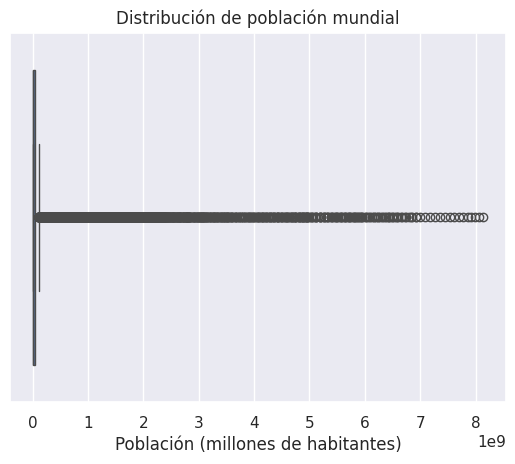

In [103]:
# Generamos un boxplot para explorar la distribución de población global
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df.copy()
sns.boxplot(
    data=df_plot,
    x='OBS_VALUE')
plt.title('Distribución de población mundial')
plt.xlabel('Población (millones de habitantes)')
plt.show()

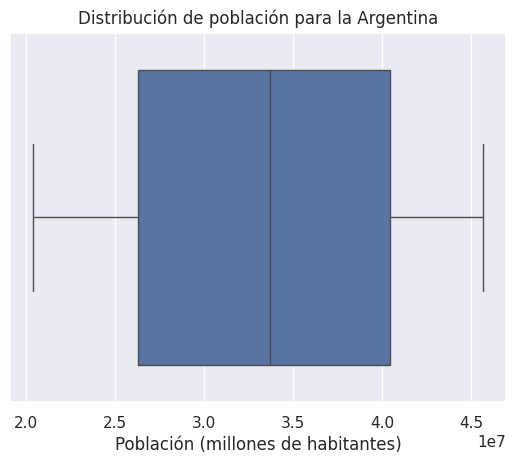

In [104]:
# Generamos un boxplot para explorar la distribución de población para la ARG
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df[df['REF_AREA'] =="ARG" ]
sns.boxplot(data=df_plot, x='OBS_VALUE')
plt.title('Distribución de población para la Argentina')
plt.xlabel('Población (millones de habitantes)')
plt.show()

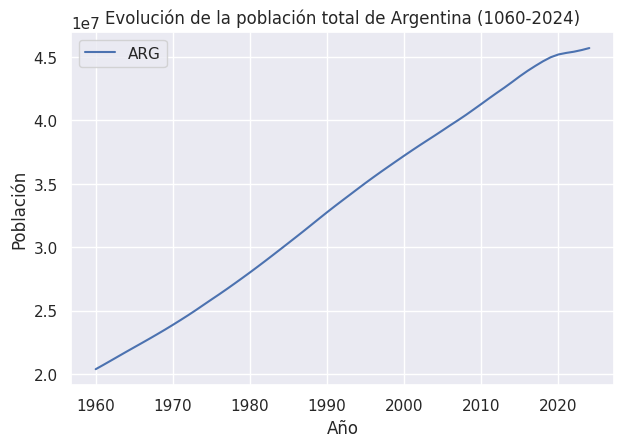

In [105]:
# libreria seaborn, metodo "lineplot" para linea de tiempo o serie de tiempo

df_plot = df[df['REF_AREA'] =="ARG" ]
sns.lineplot(
    data=df_plot, # dato o dataframe
    x='TIME_PERIOD', # variable en X
    y='OBS_VALUE', # variable en Y
    label = "ARG"
)

plt.title("Evolución de la población total de Argentina (1060-2024)")
plt.xlabel("Año") # Etiqueta en el eje X
plt.ylabel("Población") # Etiqueta en el eje X
plt.legend()
plt.tight_layout() # ajuste automatico
plt.show()

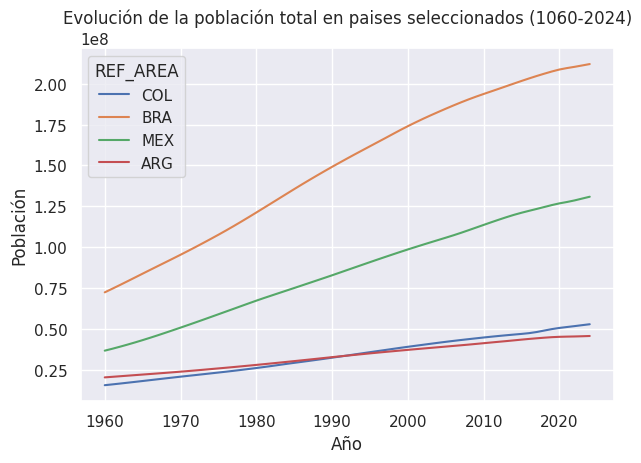

In [106]:
# libreria seaborn, metodo "lineplot" para linea de tiempo o serie de tiempo

paises_seleccionados = ['ARG', 'BRA', 'COL', 'MEX']
df_plot = df[df['REF_AREA'].isin(paises_seleccionados) ]

sns.lineplot(
    data=df_plot, # dato o dataframe
    x='TIME_PERIOD', # variable en X
    y='OBS_VALUE', # variable en Y,
    hue='REF_AREA'
)

plt.title("Evolución de la población total en paises seleccionados (1060-2024)")
plt.xlabel("Año") # Etiqueta en el eje X
plt.ylabel("Población") # Etiqueta en el eje X

plt.tight_layout() # ajuste automatico
plt.show()

# Preparar y exportar datos para Race Chart
La visualización integrada de Flourish, RaceChart, que muestra de forma dinámica la evolución de las variables por país, requiere que los datos se encuentren en formato Wide, por lo cual, convertimos el formato original Long a Wide, usando el método `pivot`.


## Convertimos formato long a wide (pivot)

In [107]:
# Pasamos de formato long a wide con pivot
# Pasamos de formato wide a long con melt
df_wide = (
    df.pivot(
        index="REF_AREA",
        columns="TIME_PERIOD",
        values="OBS_VALUE"
    )
    .reset_index()
)

In [108]:
df_wide.head()

TIME_PERIOD,REF_AREA,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ABW,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,58694.0,58990.0,59069.0,...,107906.0,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0
1,AFE,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,153281203.0,157704381.0,162329396.0,...,607123269.0,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0
2,AFG,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,10756922.0,...,33831764.0,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,AFW,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,111246953.0,113795019.0,116444636.0,...,418127845.0,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0
4,AGO,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,5581386.0,5641807.0,5702699.0,...,28157798.0,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0


## Agregamos la bandera del país

In [109]:
# Instalamos la librería para obtener el flag icon
! pip install pycountry

In [110]:
# Declaramos una función que conviert iso3 a iso2, ARG -> ar
import pycountry

def iso3_to_iso2(code):
    try:
        return pycountry.countries.get(
            alpha_3=str(code).upper()
        ).alpha_2.lower()
    except:
        return None

In [111]:
# Generamos la columna con iso2
df_wide["ISO2"] = df_wide["REF_AREA"].apply(iso3_to_iso2)

In [112]:
# Si hay nulos, es porque no pudo convertir
df_wide["ISO2"].isnull().sum()

np.int64(50)

In [113]:
# Concatenamos iso2 con FLAG_URL para obtener el icon
df_wide["FLAG_URL"] = (
    "https://flagcdn.com/w80/" +
    df_wide["ISO2"] +
    ".png"
)

In [114]:
# Visualizamos registros nulos
df_wide[df_wide.isnull().any(axis=1)]

TIME_PERIOD,REF_AREA,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2017,2018,2019,2020,2021,2022,2023,2024,ISO2,FLAG_URL
1,AFE,1.300757e+08,1.335349e+08,1.371717e+08,1.409455e+08,1.449041e+08,1.490335e+08,1.532812e+08,1.577044e+08,1.623294e+08,...,6.400587e+08,6.578011e+08,6.759502e+08,6.944461e+08,7.130909e+08,7.318214e+08,7.504914e+08,7.692809e+08,None,NaN
3,AFW,9.763092e+07,9.970667e+07,1.018548e+08,1.040892e+08,1.063884e+08,1.087726e+08,1.112470e+08,1.137950e+08,1.164446e+08,...,4.408829e+08,4.521959e+08,4.633654e+08,4.745694e+08,4.859210e+08,4.973872e+08,5.093986e+08,5.217641e+08,None,NaN
7,ARB,9.154085e+07,9.393168e+07,9.642860e+07,9.903851e+07,1.017298e+08,1.044940e+08,1.074031e+08,1.104917e+08,1.137122e+08,...,4.283159e+08,4.359981e+08,4.442813e+08,4.537232e+08,4.606466e+08,4.713521e+08,4.821060e+08,4.926126e+08,None,NaN
36,CEB,9.140131e+07,9.223138e+07,9.300859e+07,9.384002e+07,9.471580e+07,9.544099e+07,9.614634e+07,9.704327e+07,9.788402e+07,...,1.023375e+08,1.020742e+08,1.018643e+08,1.012158e+08,1.002057e+08,1.000719e+08,1.001837e+08,1.000620e+08,None,NaN
38,CHI,1.108080e+05,1.117820e+05,1.129530e+05,1.142340e+05,1.155610e+05,1.168790e+05,1.181860e+05,1.195050e+05,1.207930e+05,...,1.643190e+05,1.649490e+05,1.656390e+05,1.662350e+05,1.667410e+05,1.672150e+05,1.676910e+05,1.681260e+05,None,NaN
49,CSS,2.558348e+06,2.614258e+06,2.670187e+06,2.728278e+06,2.784804e+06,2.839698e+06,2.894435e+06,2.948759e+06,3.002786e+06,...,4.366140e+06,4.407658e+06,4.443134e+06,4.459302e+06,4.479167e+06,4.497310e+06,4.519904e+06,4.539060e+06,None,NaN
61,EAP,8.959615e+08,8.955346e+08,9.074730e+08,9.308108e+08,9.537835e+08,9.773669e+08,1.004271e+09,1.030471e+09,1.057698e+09,...,2.087239e+09,2.100699e+09,2.112290e+09,2.121866e+09,2.128554e+09,2.133560e+09,2.137528e+09,2.141122e+09,None,NaN
62,EAR,9.689094e+08,9.941768e+08,1.020131e+09,1.046697e+09,1.074021e+09,1.101264e+09,1.128475e+09,1.156817e+09,1.185937e+09,...,3.274060e+09,3.314245e+09,3.355015e+09,3.396051e+09,3.432026e+09,3.470645e+09,3.511608e+09,3.552279e+09,None,NaN
63,EAS,1.042819e+09,1.044750e+09,1.059217e+09,1.085095e+09,1.110651e+09,1.136869e+09,1.166223e+09,1.194633e+09,1.224397e+09,...,2.333476e+09,2.347576e+09,2.359762e+09,2.369421e+09,2.375118e+09,2.379617e+09,2.384441e+09,2.388319e+09,None,NaN
64,ECA,1.288105e+08,1.316179e+08,1.344004e+08,1.371878e+08,1.399740e+08,1.426686e+08,1.453715e+08,1.480880e+08,1.507776e+08,...,2.443086e+08,2.464005e+08,2.485767e+08,2.503512e+08,2.518677e+08,2.505143e+08,2.487214e+08,2.502815e+08,None,NaN


In [115]:
# Eliminamos registros nulos
df_wide.dropna(inplace=True)

In [116]:
# Cantidad de registros resultantes
df_wide.shape[0]

214

In [117]:
df_wide.head()

TIME_PERIOD,REF_AREA,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2017,2018,2019,2020,2021,2022,2023,2024,ISO2,FLAG_URL
0,ABW,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,58694.0,58990.0,59069.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,aw,https://flagcdn.com/w80/aw.png
2,AFG,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,10756922.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,af,https://flagcdn.com/w80/af.png
4,AGO,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,5581386.0,5641807.0,5702699.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,ao,https://flagcdn.com/w80/ao.png
5,ALB,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,1914573.0,1965598.0,2022272.0,...,2648285.0,2607733.0,2567801.0,2528480.0,2489762.0,2451636.0,2414095.0,2377128.0,al,https://flagcdn.com/w80/al.png
6,AND,9510.0,10283.0,11086.0,11915.0,12764.0,13634.0,14626.0,15837.0,17176.0,...,73763.0,75162.0,76474.0,77380.0,78364.0,79705.0,80856.0,81938.0,ad,https://flagcdn.com/w80/ad.png


## Exportamos a csv

In [118]:
df_wide.to_csv('poblacion_mundial_flag.csv', index=False)

# Enriquecemos REF_AREA para saber a que pais corresponde
(opcional)
La idea e usar el endpoint de metadatos, para enriquecer nuestro dataframe y mostrar, ademas del ISO3, el nombre de cada país de manera completa.

In [119]:
# Preparamos el endpoint
endpoint_metadata = "/data360/metadata"

In [120]:
# Preparamos el payload
params_metadata = {
    "query": "&$filter=series_description/idno eq 'WB_WDI_SP_POP_TOTL'"
}

In [121]:
# Hacemos la petición a la API en POST
pop_metadata = post_api(endpoint_metadata, payload = params_metadata)

In [122]:
# Exploramos las keys (complementar la vista desde Postman)
pop_metadata.keys()

dict_keys(['@odata.context', '@odata.count', 'value'])

In [123]:
# Extraemos de los metadatos, la ref_country
ref_area_country = pop_metadata['value'][0]["series_description"]["ref_country"]

In [124]:
print(f"La cantidad de paises exraidos es {len(ref_area_country)}")

La cantidad de paises exraidos es 217


In [125]:
df_ref = pd.DataFrame(ref_area_country)
df_ref.head()

,name,code
0,Aruba,ABW
1,Afghanistan,AFG
2,Angola,AGO
3,Albania,ALB
4,Andorra,AND


In [126]:
df_ref.rename(columns={'name': 'COUNTRY_NAME', 'code': 'REF_AREA'}, inplace=True)
df_ref.head()

,COUNTRY_NAME,REF_AREA
0,Aruba,ABW
1,Afghanistan,AFG
2,Angola,AGO
3,Albania,ALB
4,Andorra,AND


In [127]:
df_ref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   COUNTRY_NAME  217 non-null    object
 1   REF_AREA      217 non-null    object
dtypes: object(2)
memory usage: 3.5+ KB


In [128]:
df_enr = pd.merge(df_wide, df_ref, on='REF_AREA', how='left')
df_enr.head()

,REF_AREA,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2018,2019,2020,2021,2022,2023,2024,ISO2,FLAG_URL,COUNTRY_NAME
0,ABW,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,58694.0,58990.0,59069.0,...,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,aw,https://flagcdn.com/w80/aw.png,Aruba
1,AFG,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,10266395.0,10505959.0,10756922.0,...,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,af,https://flagcdn.com/w80/af.png,Afghanistan
2,AGO,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,5581386.0,5641807.0,5702699.0,...,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,ao,https://flagcdn.com/w80/ao.png,Angola
3,ALB,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,1914573.0,1965598.0,2022272.0,...,2607733.0,2567801.0,2528480.0,2489762.0,2451636.0,2414095.0,2377128.0,al,https://flagcdn.com/w80/al.png,Albania
4,AND,9510.0,10283.0,11086.0,11915.0,12764.0,13634.0,14626.0,15837.0,17176.0,...,75162.0,76474.0,77380.0,78364.0,79705.0,80856.0,81938.0,ad,https://flagcdn.com/w80/ad.png,Andorra


In [129]:
df_enr = df_enr.dropna()

In [130]:
df_enr.shape[0]

214

## Exportamos a csv

In [131]:
df_enr.to_csv('poblacion_mundial.csv', index=False)

# Playground

Personalizamos el gráfico!

Descargar el siguiente código html y abrirlo localmente desde un Browser

[Playground](https://drive.google.com/file/d/1-Zq05uo3VeFwQn9Lo0PWDpQRoReyB1Ch/view?usp=drive_link)

Explorar los diferentes settings, copiar el código generado en un bloque de este Notebook y ejecutarlo. Analizar cada uno de los bloques y sus posibles settings.

In [132]:
# Pega el código del Playground aquí

# Bonus track
Ya probaste [Flourish](https://flourish.studio/)?

Podes importar el csv y generar una serie de tiempo que luego podes importar en un proyecto o sitio web. Tambien podes hacer un chart race!
Pensemos como representar la evolucion de la poblacion mundial a partir de la API del Banco Mundial!